In [5]:
import pandas as pd
from PIL import Image
import os
import sys
import json
import random
import torch
import torch.nn as nn
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from pytorch_grad_cam import GradCAM
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from sklearn.metrics import f1_score

In [6]:
%matplotlib inline

In [7]:
# Base Path
base_path = "E://OVGU_NOTES//Machine_Learning_Safety//assignment//Data_set//"

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [9]:
# Dataset Class
class CarlaDataset(Dataset):
    def __init__(self, csv_file, img_dir, label_column, transform=None):
        self.labels = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.label_column = label_column
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        row = self.labels.iloc[idx]

        frame = str(row['frame']).zfill(6)

        img_path = f"{self.img_dir}/{frame}.jpg"

        image = Image.open(img_path).convert("RGB")

        label = float(row[self.label_column])

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label)

In [10]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [11]:
# Load Vehicle Model
model_vehicle = models.resnet18(weights=None)

model_vehicle.fc = nn.Linear(
    model_vehicle.fc.in_features,
    1
)

model_vehicle.load_state_dict(
    torch.load(
        "vehicle.pth",
        map_location=device
    )
)

model_vehicle = model_vehicle.to(device)

model_vehicle.eval()

print("Vehicle model loaded")

Vehicle model loaded


In [12]:
# Load Pedestrian Model
model_pedestrian = models.resnet18(weights=None)

model_pedestrian.fc = nn.Linear(
    model_pedestrian.fc.in_features,
    1
)

model_pedestrian.load_state_dict(
    torch.load(
        "pedestrian.pth",
        map_location=device
    )
)

model_pedestrian = model_pedestrian.to(device)

model_pedestrian.eval()

print("Pedestrian model loaded")

Pedestrian model loaded


In [13]:
# Load Traffic Model
model_traffic = models.resnet18(weights=None)

model_traffic.fc = nn.Linear(
    model_traffic.fc.in_features,
    1
)

model_traffic.load_state_dict(
    torch.load(
        "traffic.pth",
        map_location=device
    )
)

model_traffic = model_traffic.to(device)

model_traffic.eval()

print("Traffic-light model loaded")

Traffic-light model loaded


In [14]:
# Create Test Datasets
test_vehicle = CarlaDataset(
    f"{base_path}/test/labels.csv",
    f"{base_path}/test/rgb-front",
    "has_vehicle",
    transform
)

test_pedestrian = CarlaDataset(
    f"{base_path}/test/labels.csv",
    f"{base_path}/test/rgb-front",
    "has_pedestrian",
    transform
)

test_traffic = CarlaDataset(
    f"{base_path}/test/labels.csv",
    f"{base_path}/test/rgb-front",
    "has_traffic_light",
    transform
)

# 7.4

In [15]:
# Part 1: Compute ECE
# Cell 1: ECE Function
import numpy as np

def compute_ece(confidences, predictions, labels, n_bins=10):

    bin_boundaries = np.linspace(0, 1, n_bins + 1)

    ece = 0.0

    for i in range(n_bins):

        lower = bin_boundaries[i]
        upper = bin_boundaries[i + 1]

        mask = (confidences > lower) & (confidences <= upper)

        if np.sum(mask) > 0:

            bin_accuracy = np.mean(
                predictions[mask] == labels[mask]
            )

            bin_confidence = np.mean(
                confidences[mask]
            )

            bin_weight = np.sum(mask) / len(labels)

            ece += np.abs(
                bin_accuracy - bin_confidence
            ) * bin_weight

    return ece

In [16]:
# Cell 2: Collect Predictions
def get_predictions(model, dataset):

    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False
    )

    model.eval()

    confidences = []
    predictions = []
    labels_list = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            preds = (probs > 0.5).float()

            confidences.extend(
                probs.cpu().numpy().flatten()
            )

            predictions.extend(
                preds.cpu().numpy().flatten()
            )

            labels_list.extend(
                labels.numpy().flatten()
            )

    return (
        np.array(confidences),
        np.array(predictions),
        np.array(labels_list)
    )

In [17]:
# Cell 3: Vehicle ECE
vehicle_conf, vehicle_pred, vehicle_true = \
    get_predictions(
        model_vehicle,
        test_vehicle
    )

vehicle_ece = compute_ece(
    vehicle_conf,
    vehicle_pred,
    vehicle_true
)

print("Vehicle ECE:", vehicle_ece)

Vehicle ECE: 0.1540953371715214


In [18]:
# Pedestrian ECE
ped_conf, ped_pred, ped_true = \
    get_predictions(
        model_pedestrian,
        test_pedestrian
    )

ped_ece = compute_ece(
    ped_conf,
    ped_pred,
    ped_true
)

print("Pedestrian ECE:", ped_ece)

Pedestrian ECE: 0.7209986714340954


In [19]:
# Traffic Light ECE
traffic_conf, traffic_pred, traffic_true = \
    get_predictions(
        model_traffic,
        test_traffic
    )

traffic_ece = compute_ece(
    traffic_conf,
    traffic_pred,
    traffic_true
)

print("Traffic ECE:", traffic_ece)

Traffic ECE: 0.2580268558787389


In [20]:
# Part 2: Reliability Diagram
def reliability_diagram(
        confidences,
        predictions,
        labels,
        title,
        n_bins=10):

    bins = np.linspace(0,1,n_bins+1)

    accuracies = []
    avg_confidences = []

    for i in range(n_bins):

        mask = (
            (confidences > bins[i])
            &
            (confidences <= bins[i+1])
        )

        if np.sum(mask) > 0:

            accuracies.append(
                np.mean(
                    predictions[mask]
                    ==
                    labels[mask]
                )
            )

            avg_confidences.append(
                np.mean(
                    confidences[mask]
                )
            )

    plt.figure(figsize=(6,6))

    plt.plot(
        [0,1],
        [0,1],
        '--'
    )

    plt.plot(
        avg_confidences,
        accuracies,
        marker='o'
    )

    plt.xlabel("Confidence")

    plt.ylabel("Accuracy")

    plt.title(title)

    plt.grid()

    plt.show()

In [ ]:
# Accuracy < Confidence (Overconfident)
# Accuracy > Confidence (Underconfident)

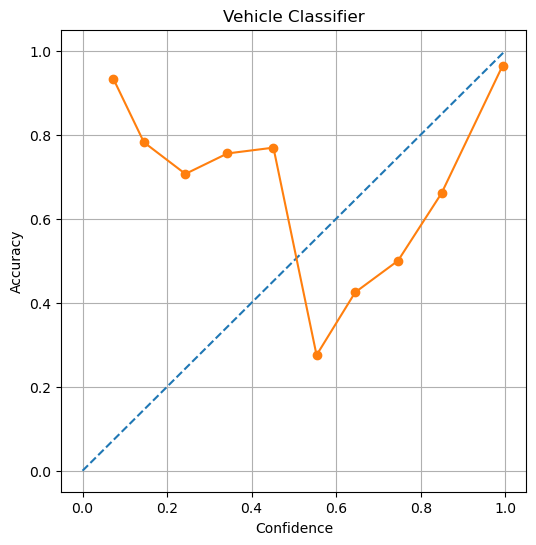

In [21]:
# Vehicle Diagram
# Here we can see that Confidence ≈ 0.10 and Accuracy ≈ 0.93 , so the model is only 10% confidence but it is correctly 93% of the time.
# So the model is underconfident
reliability_diagram(
    vehicle_conf,
    vehicle_pred,
    vehicle_true,
    "Vehicle Classifier"
)

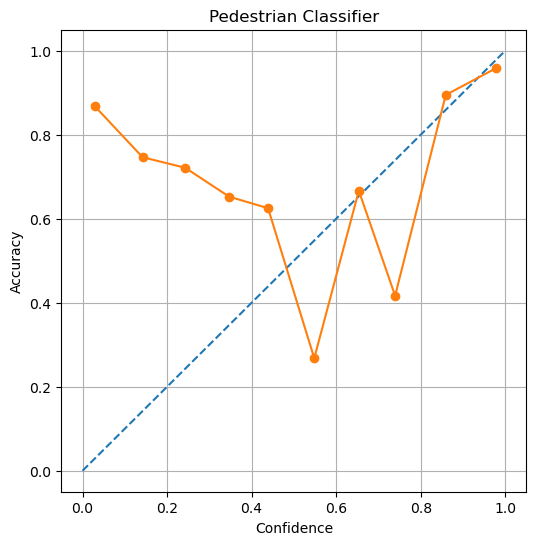

In [22]:
# Pedestrian Diagram
reliability_diagram(
    ped_conf,
    ped_pred,
    ped_true,
    "Pedestrian Classifier"
)

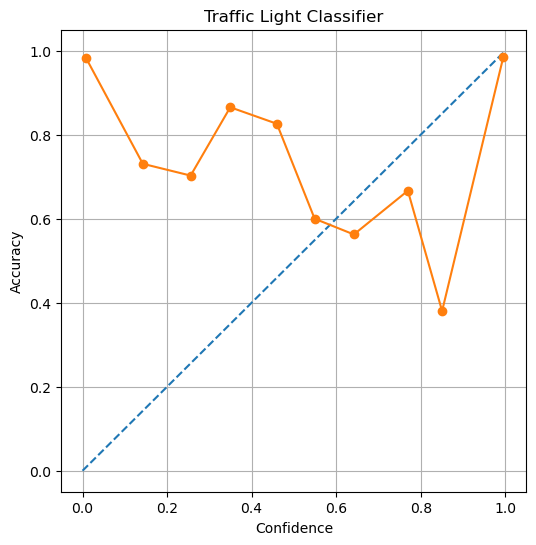

In [23]:
# Traffic Diagram
reliability_diagram(
    traffic_conf,
    traffic_pred,
    traffic_true,
    "Traffic Light Classifier"
)

# 7.5

In [24]:
# Create Validation Datasets
val_vehicle = CarlaDataset(
    f"{base_path}/validation/labels.csv",
    f"{base_path}/validation/rgb-front",
    "has_vehicle",
    transform
)

val_pedestrian = CarlaDataset(
    f"{base_path}/validation/labels.csv",
    f"{base_path}/validation/rgb-front",
    "has_pedestrian",
    transform
)

val_traffic = CarlaDataset(
    f"{base_path}/validation/labels.csv",
    f"{base_path}/validation/rgb-front",
    "has_traffic_light",
    transform
)

In [25]:
# Step 2: Temperature Scaling Optimization
def find_best_temperature(model, dataset, device):

    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False
    )

    temperatures = np.arange(
        0.5,
        3.1,
        0.1
    )

    best_T = 1.0
    best_nll = float('inf')

    criterion = nn.BCEWithLogitsLoss()

    model.eval()

    for T in temperatures:

        total_loss = 0.0
        total_samples = 0

        with torch.no_grad():

            for images, labels in loader:

                images = images.to(device)

                labels = (
                    labels
                    .float()
                    .unsqueeze(1)
                    .to(device)
                )

                logits = model(images)

                scaled_logits = logits / T

                loss = criterion(
                    scaled_logits,
                    labels
                )

                total_loss += (
                    loss.item()
                    *
                    labels.size(0)
                )

                total_samples += labels.size(0)

        avg_nll = total_loss / total_samples

        if avg_nll < best_nll:

            best_nll = avg_nll
            best_T = T

    return best_T, best_nll

In [26]:
# Step 3: Find Best T for All Models

vehicle_T, vehicle_nll = find_best_temperature(
    model_vehicle,
    val_vehicle,
    device
)

print("Vehicle T =", vehicle_T)

Vehicle T = 1.5999999999999996


In [27]:
pedestrian_T, pedestrian_nll = find_best_temperature(
    model_pedestrian,
    val_pedestrian,
    device
)

print("Pedestrian T =", pedestrian_T)

Pedestrian T = 2.6999999999999993


In [28]:
traffic_T, traffic_nll = find_best_temperature(
    model_traffic,
    val_traffic,
    device
)

print("Traffic T =", traffic_T)

Traffic T = 1.2999999999999998


In [29]:
# ECE After Temperature Scaling
def get_scaled_predictions(
        model,
        dataset,
        temperature):

    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False
    )

    confidences = []
    predictions = []
    labels_list = []

    model.eval()

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            logits = model(images)

            logits = logits / temperature

            probs = torch.sigmoid(logits)

            preds = (
                probs > 0.5
            ).float()

            confidences.extend(
                probs.cpu().numpy().flatten()
            )

            predictions.extend(
                preds.cpu().numpy().flatten()
            )

            labels_list.extend(
                labels.numpy().flatten()
            )

    return (
        np.array(confidences),
        np.array(predictions),
        np.array(labels_list)
    )

In [30]:
# Vehicle ECE After Scaling
vehicle_conf_scaled, vehicle_pred_scaled, vehicle_true_scaled = \
    get_scaled_predictions(
        model_vehicle,
        test_vehicle,
        vehicle_T
    )

vehicle_ece_scaled = compute_ece(
    vehicle_conf_scaled,
    vehicle_pred_scaled,
    vehicle_true_scaled
)

print(vehicle_ece_scaled)

0.12039935890585185


In [31]:
# Pedestrian ECE After Scaling
ped_conf_scaled, ped_pred_scaled, ped_true_scaled = \
    get_scaled_predictions(
        model_pedestrian,
        test_pedestrian,
        pedestrian_T
    )

ped_ece_scaled = compute_ece(
    ped_conf_scaled,
    ped_pred_scaled,
    ped_true_scaled
)

print(ped_ece_scaled)

0.5642990398034453


In [32]:
# Traffic ECE After Scaling
traffic_conf_scaled, traffic_pred_scaled, traffic_true_scaled = \
    get_scaled_predictions(
        model_traffic,
        test_traffic,
        traffic_T
    )

traffic_ece_scaled = compute_ece(
    traffic_conf_scaled,
    traffic_pred_scaled,
    traffic_true_scaled
)

print(traffic_ece_scaled)

0.24841818487944287


In [33]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Vehicle",
        "Pedestrian",
        "Traffic Light"
    ],
    
    "Best Temperature (T)": [
        vehicle_T,
        pedestrian_T,
        traffic_T
    ],
    
    "ECE Before Scaling": [
        vehicle_ece,
        ped_ece,
        traffic_ece
    ],
    
    "ECE After Scaling": [
        vehicle_ece_scaled,
        ped_ece_scaled,
        traffic_ece_scaled
    ]
})

results["ECE Improvement"] = (
    results["ECE Before Scaling"]
    -
    results["ECE After Scaling"]
)

print(results)

           Model  Best Temperature (T)  ECE Before Scaling  ECE After Scaling  \
0        Vehicle                   1.6            0.154095           0.120399   
1     Pedestrian                   2.7            0.720999           0.564299   
2  Traffic Light                   1.3            0.258027           0.248418   

   ECE Improvement  
0         0.033696  
1         0.156700  
2         0.009609  


In [34]:
results = results.round(4)

print(results)

           Model  Best Temperature (T)  ECE Before Scaling  ECE After Scaling  \
0        Vehicle                   1.6              0.1541             0.1204   
1     Pedestrian                   2.7              0.7210             0.5643   
2  Traffic Light                   1.3              0.2580             0.2484   

   ECE Improvement  
0           0.0337  
1           0.1567  
2           0.0096  


# 7.6

In [35]:
# Cost Function
CFN = 100
CFP = 1

tau_star = 0.0099

In [38]:
# Evaluation Function

# This function computes:

# False Positives
# False Negatives
# Total Loss

from sklearn.metrics import confusion_matrix
def evaluate_cost(
        model,
        dataset,
        threshold,
        device,
        temperature=None):

    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False
    )

    y_true = []
    y_pred = []

    model.eval()

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            logits = model(images)

            if temperature is not None:
                logits = logits / temperature

            probs = torch.sigmoid(logits)

            preds = (
                probs >= threshold
            ).float()

            y_true.extend(
                labels.numpy()
            )

            y_pred.extend(
                preds.cpu().numpy().flatten()
            )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    total_loss = (
        CFN * fn
        +
        CFP * fp
    )

    return fp, fn, total_loss

In [39]:
# Uncalibrated Model, τ = 0.5
fp1, fn1, loss1 = evaluate_cost(
    model_pedestrian,
    test_pedestrian,
    threshold=0.5,
    device=device
)

print(loss1)

57276


In [40]:
# Uncalibrated Model, τ = τ*
fp2, fn2, loss2 = evaluate_cost(
    model_pedestrian,
    test_pedestrian,
    threshold=tau_star,
    device=device
)

print(loss2)

8934


In [41]:
# Calibrated Model, τ = 0.5
fp3, fn3, loss3 = evaluate_cost(
    model_pedestrian,
    test_pedestrian,
    threshold=0.5,
    device=device,
    temperature=pedestrian_T
)

print(loss3)

57276


In [42]:
# Calibrated Model, τ = τ*
fp4, fn4, loss4 = evaluate_cost(
    model_pedestrian,
    test_pedestrian,
    threshold=tau_star,
    device=device,
    temperature=pedestrian_T
)

print(loss4)

2894


In [43]:
# Create the Required 2×2 Table
import pandas as pd

cost_table = pd.DataFrame(
    {
        "τ = 0.5": [
            loss1,
            loss3
        ],
        "τ = τ* (0.0099)": [
            loss2,
            loss4
        ]
    },
    index=[
        "Uncalibrated",
        "Calibrated"
    ]
)

print(cost_table)

              τ = 0.5  τ = τ* (0.0099)
Uncalibrated    57276             8934
Calibrated      57276             2894


In [44]:
# Find the Best Combination
best_loss = cost_table.min().min()

print(
    "Lowest Total Loss =",
    best_loss
)

Lowest Total Loss = 2894
